# Monitor Magnetometer Analysis

valid for anlayzing data from "MonitorMagnetometer"

In [94]:
# NOTE (master-satellite): narrowed from ["Monitor"] to ["MonitorMagnetometer"].
# "Monitor" also matched MonitorSPCMinApplet (228 files), MonitorFORTWithLuca (143)
# and MonitorMOTandExternalBeamPositions (78) -- none of which write the Coils_settings
# this notebook reads. The filter now matches MonitorMagnetometer and
# MonitorMagnetometerSynchronous only.
#
# There is no master-satellite magnetometer monitor yet: tests/A6-MonitorMagnetometer.py
# is standalone-only, and no such run exists after the changeover, so this notebook
# still reads pre-changeover data until that experiment is ported.
date_filters = ["2026-07-24", "2026-07-31", "2026-08-01", "2026-08-03"]

# date_filters = ["2026-07-22"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints

sys.path.append("..\\")
# from h5_data_utilities import * # helper functions for dealing with h5 files
from h5_data_utilities import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["MonitorMagnetometer"], # match files containing ANY of these strings (get_files_by_criteria uses any())
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=False
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['Coils_settings'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:
            print(f"oops... something wrong with {f}")

found 32 files
file 0 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-24\11\000018638-MonitorMagnetometer.h5) scanned over MOT
file 1 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-24\11\000018638-MonitorMagnetometerSynchronous.h5) scanned over MOT
file 2 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-24\11\000018640-MonitorMagnetometer.h5) scanned over MOT
file 3 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-24\11\000018640-MonitorMagnetometerSynchronous.h5) scanned over MOT
file 4 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-24\11\000018641-MonitorMagnetometer.h5) scanned over MOT
file 5 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-24\11\000018641-MonitorMagnetometerSynchronous.h5) scanned over MOT
file 6 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-24\11\000018642-MonitorMagnetometer.h5) scanned over MOT
file 7 (C:\Networking Experiment\ar

In [96]:
file_indices ={
    # 11:''
    # 12:''

    # 15:'',
    
    # 19:''
    # 22:''
    # 24:''
    #### average=1, every 2ms
    # 27:'2026-08-01 MOT',
    # 29:'2026-08-03 zerovolts - with scope on top',
    31:'2026-08-03 zerovolts - without scope on top'

}

# for idx,f_item in enumerate(file_indices.items()):
#     f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
#     f = h5py.File(os.path.join(results, fnames[f_idx]))
#     rid = f['rid'][()]
#     ms_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    
# n_files = len(file_indices)
# fig, axes = plt.subplots(3, n_files, figsize=(10, 10), squeeze=False, sharex="col")

# for col, (f_idx, f_comment) in enumerate(file_indices.items()):
#     with h5py.File(os.path.join(results, fnames[f_idx]), "r") as f:
#         rid = f["rid"][()]
#         d = {}
#         ms_archive_and_datasets_to_locals(f, parent_locals=d, quiet=True)

#     for row, axis_name in enumerate(["X", "Y", "Z"]):
#         data = np.asarray(d[f"Magnetometer_{axis_name}"])[1:]
#         axes[row, col].plot(data)
#         axes[row, col].set_ylabel(f"Magnetometer {axis_name}")
#         axes[row, col].grid(alpha=0.3)

#     axes[0, col].set_title(f"RID {rid}: {f_comment}")
#     axes[2, col].set_xlabel("Measurement index")

# plt.tight_layout()
# plt.show()

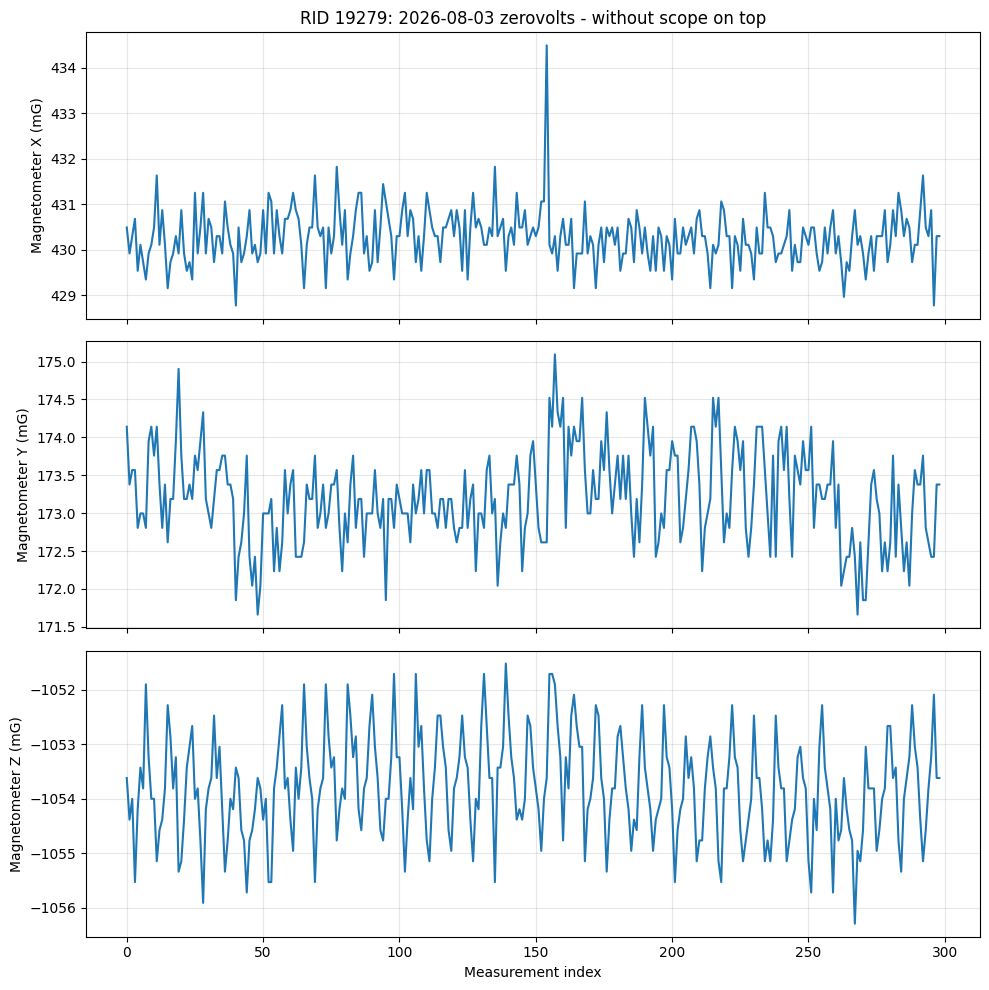

In [97]:
V_to_mG = 625

for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    ms_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    
n_files = len(file_indices)
fig, axes = plt.subplots(3, n_files, figsize=(10, 10), squeeze=False, sharex="col")

for col, (f_idx, f_comment) in enumerate(file_indices.items()):
    with h5py.File(os.path.join(results, fnames[f_idx]), "r") as f:
        rid = f["rid"][()]
        d = {}
        ms_archive_and_datasets_to_locals(f, parent_locals=d, quiet=True)

    for row, axis_name in enumerate(["X", "Y", "Z"]):
        data = np.asarray(d[f"Magnetometer_{axis_name}"])[201:500] * V_to_mG
        axes[row, col].plot(data)
        axes[row, col].set_ylabel(f"Magnetometer {axis_name} (mG)")
        axes[row, col].grid(alpha=0.3)

    axes[0, col].set_title(f"RID {rid}: {f_comment}")
    axes[2, col].set_xlabel("Measurement index")

plt.tight_layout()
plt.show()

In [89]:
t_step_ms

np.int32(2)

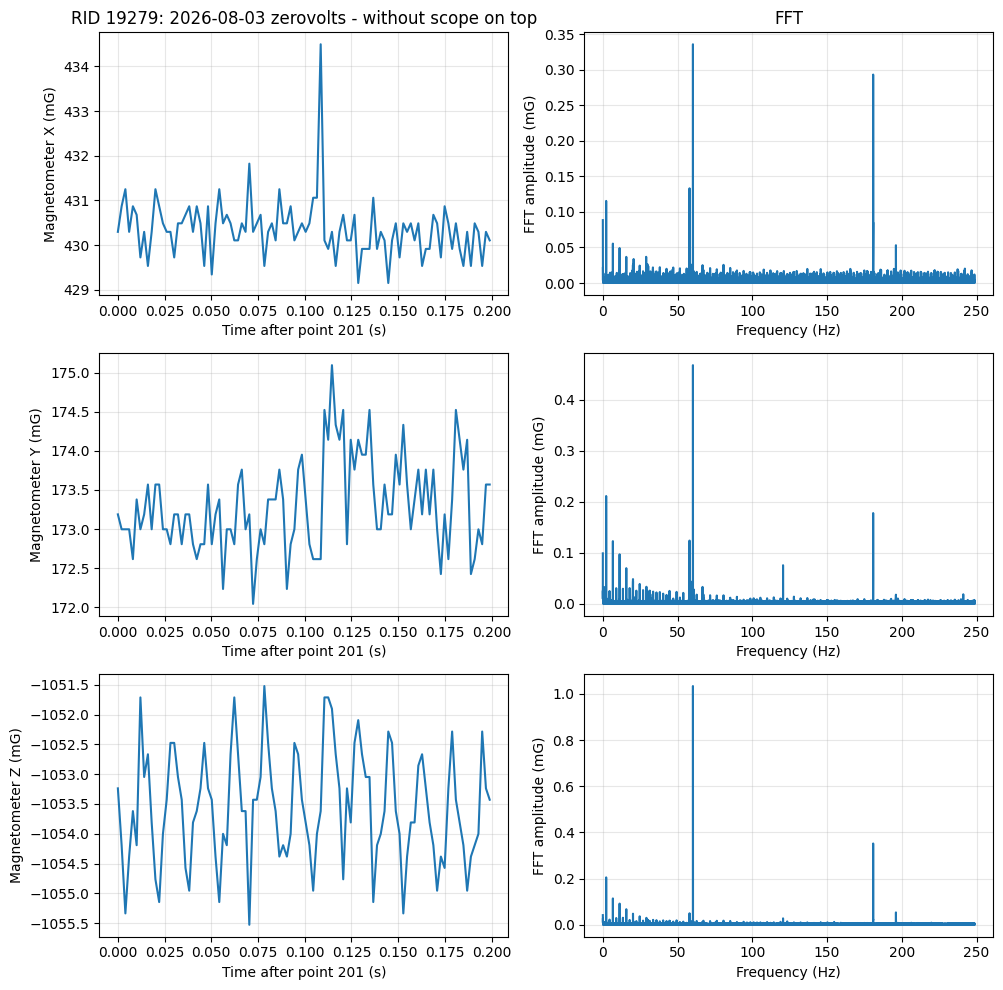

Peak 1 (Hz)  \
RID   Comment                                     Axis                
19279 2026-08-03 zerovolts - without scope on top X          60.285   
                                                  Y          60.285   
                                                  Z          60.285   

                                                        Peak 2 (Hz)  \
RID   Comment                                     Axis                
19279 2026-08-03 zerovolts - without scope on top X         180.854   
                                                  Y           2.238   
                                                  Z         180.854   

                                                        Peak 3 (Hz)  \
RID   Comment                                     Axis                
19279 2026-08-03 zerovolts - without scope on top X          58.007   
                                                  Y           2.248   
                                                  Z           2.238   

                                                        Peak 4 (Hz)  \
RID   Comment                                     Axis                
19279 2026-08-03 zerovolts - without scope on top X           2.238   
                                                  Y         180.854   
                                                  Z           6.730   

                                                        Peak 5 (Hz)  \
RID   Comment                                     Axis                
19279 2026-08-03 zerovolts - without scope on top X           6.730   
                                                  Y          58.007   
                                                  Z          11.216   

                                                        Peak 6 (Hz)  \
RID   Comment                                     Axis                
19279 2026-08-03 zerovolts - without scope on top X         196.089   
                                                  Y           6.730   
                                                  Z          60.265   

                                                        Peak 7 (Hz)  \
RID   Comment                                     Axis                
19279 2026-08-03 zerovolts - without scope on top X          11.216   
                                                  Y          11.216   
                                                  Z          15.703   

                                                        Peak 8 (Hz)  \
RID   Comment                                     Axis                
19279 2026-08-03 zerovolts - without scope on top X          29.003   
                                                  Y         120.569   
                                                  Z          60.305   

                                                        Peak 9 (Hz)  \
RID   Comment                                     Axis                
19279 2026-08-03 zerovolts - without scope on top X          15.703   
                                                  Y          15.703   
                                                  Z         196.089   

                                                        Peak 10 (Hz)  
RID   Comment                                     Axis                
19279 2026-08-03 zerovolts - without scope on top X           20.603  
                                                  Y           20.185  
                                                  Z           58.007

In [101]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

V_to_mG = 625

# n_average = 10
# t_step_ms = 1
n_peaks_to_show = 10
minimum_frequency = 0.5

measurement_time_ms = n_average * 0.010
dt = (measurement_time_ms + t_step_ms) * 1e-3

fft_peak_results = []
n_files = len(file_indices)
fig, axes = plt.subplots(3, 2 * n_files, figsize=(10 * n_files, 10), squeeze=False)

for col, (f_idx, f_comment) in enumerate(file_indices.items()):
    with h5py.File(os.path.join(results, fnames[f_idx]), "r") as f:
        rid = f["rid"][()]
        d = {}
        ms_archive_and_datasets_to_locals(f, parent_locals=d, quiet=True)

    for row, axis_name in enumerate(["X", "Y", "Z"]):
        raw_data = np.asarray(d[f"Magnetometer_{axis_name}"], dtype=float)  * V_to_mG

        # FFT uses all stabilized data; time plot shows only indices 201–500
        data = raw_data[201:]
        display_data = raw_data[301:401]
        display_time = np.arange(len(display_data)) * dt

        # Remove DC offset and apply Hann window
        window = np.hanning(len(data))
        fft_input = (data - np.mean(data)) * window
        frequencies = np.fft.rfftfreq(len(data), d=dt)
        fft_amplitude = 2 * np.abs(np.fft.rfft(fft_input)) / np.sum(window)

        # Find the strongest FFT peaks
        valid = frequencies >= minimum_frequency
        valid_idx = np.where(valid)[0]
        peak_idx, _ = find_peaks(fft_amplitude[valid], prominence=0.01 * np.max(fft_amplitude[valid]))
        peak_idx = valid_idx[peak_idx]
        peak_idx = peak_idx[np.argsort(fft_amplitude[peak_idx])[::-1]][:n_peaks_to_show]

        for rank, i in enumerate(peak_idx, 1):
            fft_peak_results.append({
                "RID": rid,
                "Comment": f_comment,
                "Axis": axis_name,
                "Rank": rank,
                "Frequency (Hz)": frequencies[i],
                "Amplitude": fft_amplitude[i],
            })

        ax_time, ax_fft = axes[row, 2 * col], axes[row, 2 * col + 1]

        ax_time.plot(display_time, display_data)
        ax_time.set_xlabel("Time after point 201 (s)")
        ax_time.set_ylabel(f"Magnetometer {axis_name} (mG)")
        ax_time.grid(alpha=0.3)

        ax_fft.plot(frequencies[1:], fft_amplitude[1:])
        ax_fft.set_xlabel("Frequency (Hz)")
        ax_fft.set_ylabel("FFT amplitude (mG)")
        ax_fft.grid(alpha=0.3)

    axes[0, 2 * col].set_title(f"RID {rid}: {f_comment}")
    axes[0, 2 * col + 1].set_title("FFT")

plt.tight_layout()
plt.show()

fft_peak_df = pd.DataFrame(fft_peak_results)
frequency_table = fft_peak_df.pivot_table(index=["RID", "Comment", "Axis"], columns="Rank", values="Frequency (Hz)")
frequency_table.columns = [f"Peak {rank} (Hz)" for rank in frequency_table.columns]
display(frequency_table.round(3))